# Zainab Ali Alsharait - 2230006803 - 8FA2
# ARTI406 - Machine Learning
# Assignment 1: Exploratory Data Analysis (EDA)
## Dataset: Video Game Sales

## Introduction

This dataset contains video game sales data from 1980 to 2020.
It includes information about game names, platforms, genres, publishers, and sales figures across different regions (North America, Europe, Japan, and Other).

The goal of this EDA is to:
- Understand the distribution of game sales
- Identify the top selling games, genres and platforms
- Compare sales across different regions
- Analyze how game sales have changed over time

### Importing Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

### Loading Dataset

In [2]:
df = pd.read_csv("vgsales.csv")
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


### Check Missing Values

In [3]:
print(df.isna().sum())

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


In [4]:
# Show data BEFORE cleaning
print("=== BEFORE CLEANING ===")
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isna().sum())
print("\nYear data type:", df['Year'].dtype)
print("\nSample of Year column:")
print(df['Year'].head())

=== BEFORE CLEANING ===
Shape: (16598, 11)

Missing Values:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

Year data type: float64

Sample of Year column:
0    2006.0
1    1985.0
2    2008.0
3    2009.0
4    1996.0
Name: Year, dtype: float64


### Handle Missing Values

In [5]:
df.dropna(subset=['Year', 'Publisher'], inplace=True)
print("Remaining rows:", df.shape[0])

Remaining rows: 16291


### Check Duplicate Rows

In [6]:
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### Number of Rows and Columns

In [7]:
print("shape (rows, columns):", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

shape (rows, columns): (16291, 11)
Number of rows: 16291
Number of columns: 11


### Check Data Type

In [8]:
df.dtypes

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

### Fixing Year Data Type

In [9]:
df['Year'] = df['Year'].astype(int)
df.dtypes

Rank              int64
Name             object
Platform         object
Year              int64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [10]:
# Show data AFTER cleaning
print("=== AFTER CLEANING ===")
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isna().sum())
print("\nYear data type:", df['Year'].dtype)
print("\nSample of Year column:")
print(df['Year'].head())

=== AFTER CLEANING ===
Shape: (16291, 11)

Missing Values:
Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

Year data type: int64

Sample of Year column:
0    2006
1    1985
2    2008
3    2009
4    1996
Name: Year, dtype: int64


### Why Data Cleaning Was Needed
The dataset had the following issues that needed to be fixed:
- **Missing Values:** The Year column had 271 missing values and Publisher had 58 missing values. These need to be removed to avoid errors in analysis.
- **Incorrect Data Type:** The Year column was stored as float64 instead of int64. This needed to be fixed for proper time-based analysis.

**Before Cleaning**
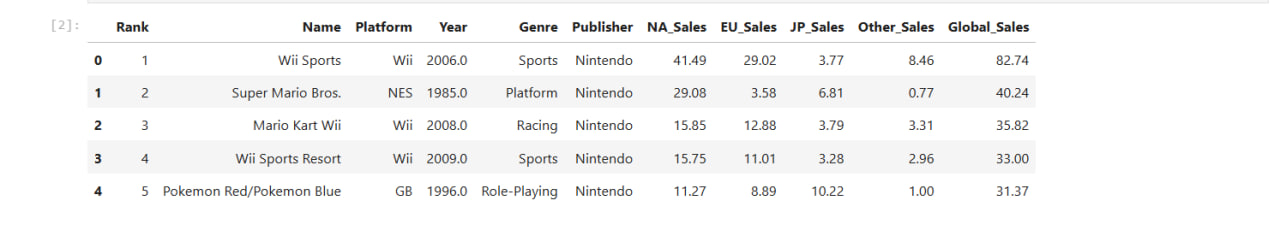
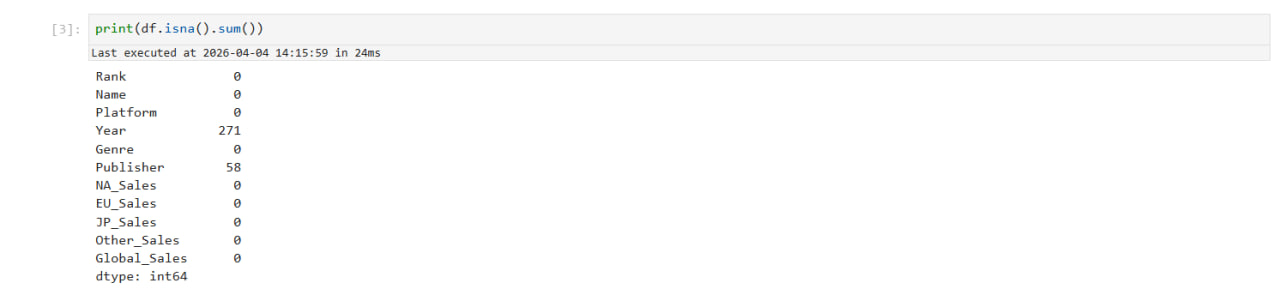

**After Cleaning**
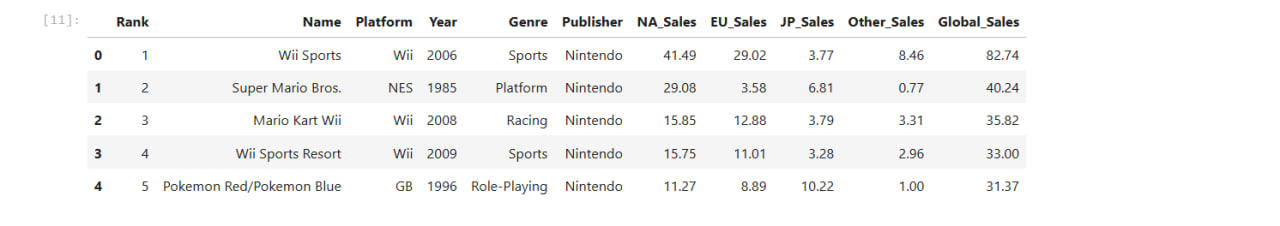
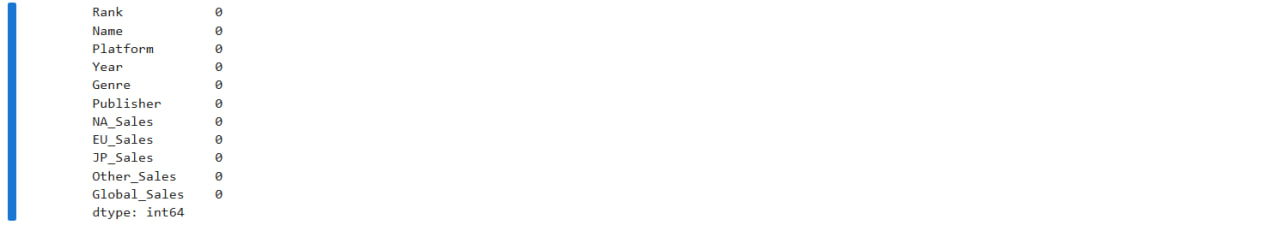

### Descriptive Statistics

In [11]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000,16291.000000
mean,8290.190228,2006.405561,0.265647,0.147731,0.078833,0.048426,0.540910
std,4792.654450,5.832412,0.822432,0.509303,0.311879,0.190083,1.567345
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4132.500000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8292.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12439.500000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


## Univariate Analysis
### Distribution of Global Sales

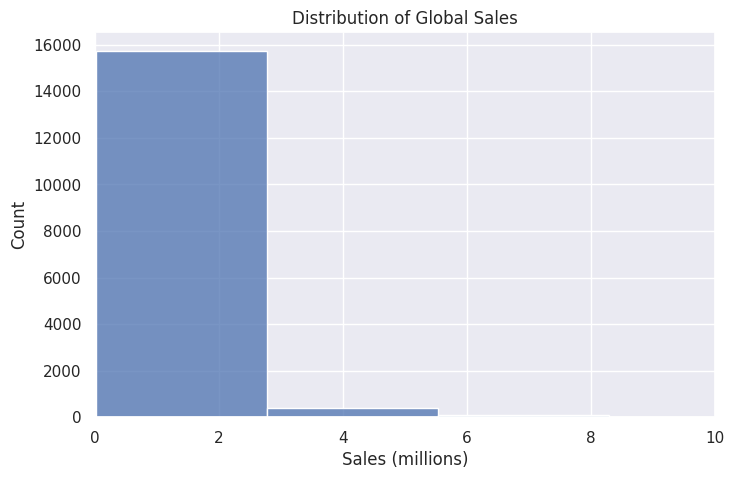

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Global_Sales'], bins=30)
plt.title("Distribution of Global Sales")
plt.xlabel("Sales (millions)")
plt.xlim(0, 10)
plt.show()

*A histogram was chosen to show the distribution and frequency of Global Sales values*
- The majority of games (~15,700) sell less than 2.5 million copies
- Very few games achieve high global sales
- This is a right-skewed distribution, meaning most games have low sales
  

### Distribution of NA Sales

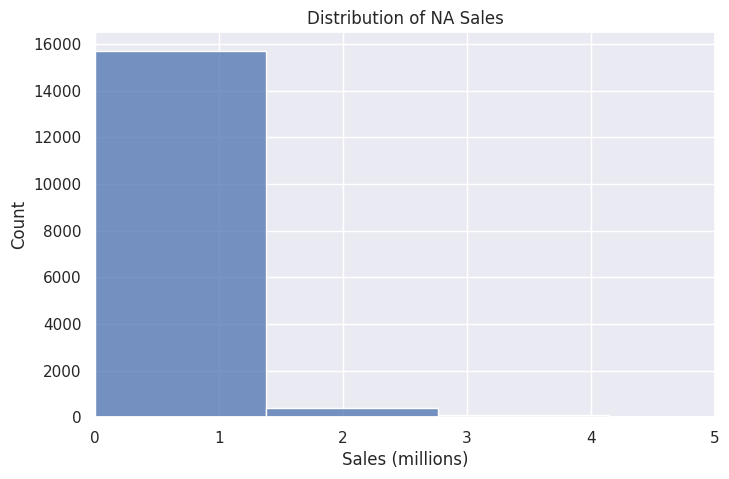

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['NA_Sales'], bins=30)
plt.title("Distribution of NA Sales")
plt.xlabel("Sales (millions)")
plt.xlim(0, 5)
plt.show()

*A histogram was chosen to show the distribution and frequency of NA Sales values*
- The majority of NA games sell less than 1 million copies
- Very few games achieve high sales in North America
- This is a right-skewed distribution, similar to Global Sales

### Top 10 Best Selling Games

<Figure size 1000x500 with 0 Axes>

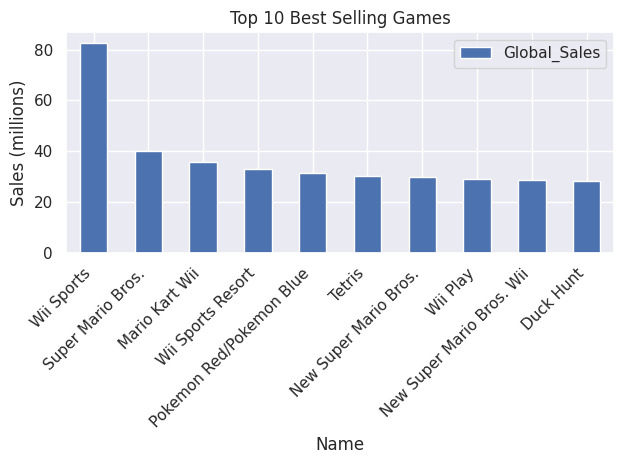

In [14]:
top10 = df.nlargest(10, 'Global_Sales')[['Name', 'Global_Sales']]

plt.figure(figsize=(10,5))
top10.plot(kind='bar', x='Name', y='Global_Sales')
plt.title("Top 10 Best Selling Games")
plt.ylabel("Sales (millions)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*A bar chart was chosen to easily compare sales values across different games*
- Wii Sports is the best selling game with over 82 million copies
- Super Mario Bros and Mario Kart Wii follow in 2nd and 3rd place
- Classic games like Tetris and Mario appear in the top 10

## Bivariate Analysis
### Sales by Genre

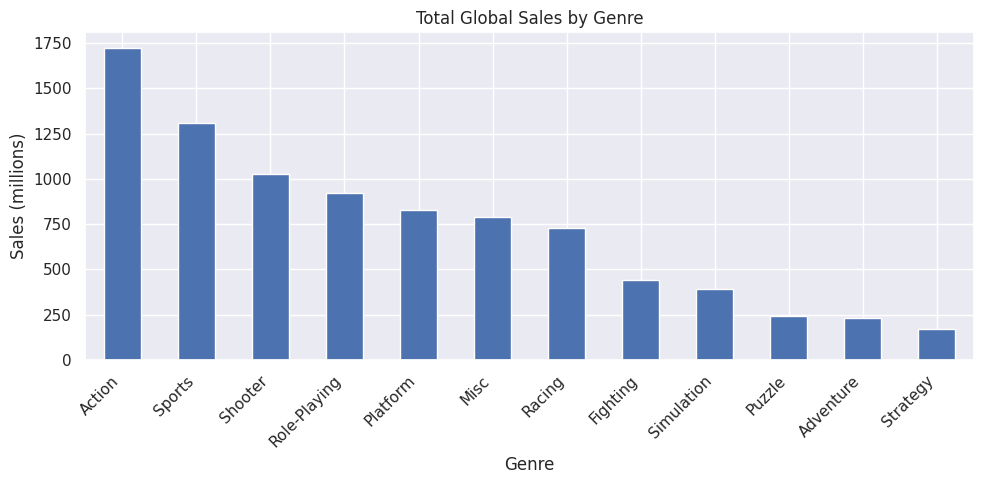

In [15]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
genre_sales.plot(kind='bar')
plt.title("Total Global Sales by Genre")
plt.ylabel("Sales (millions)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*A bar chart was chosen to compare total sales across different game genres*
- Action is the highest selling genre with the most global sales
- Sports and Shooter follow in 2nd and 3rd place
- Action games dominate the gaming market overall

### Sales by Platform

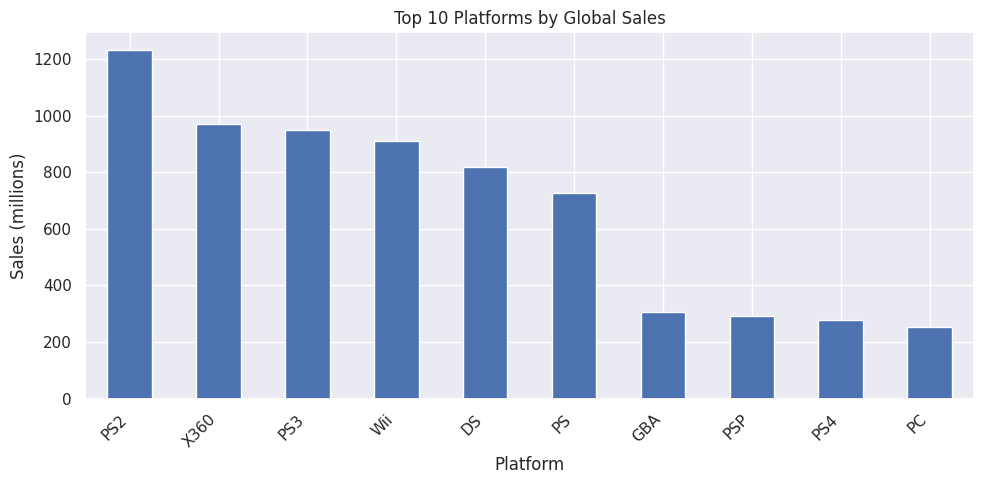

In [16]:
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
platform_sales.plot(kind='bar')
plt.title("Top 10 Platforms by Global Sales")
plt.ylabel("Sales (millions)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*A bar chart was chosen to compare total sales across the top 10 gaming platforms*
- PS2 is the highest selling platform with the most global sales
- It is followed by other popular consoles like X360 and PS3
- Older consoles like PS2 dominate due to their large game libraries

### Regional Sales Comparison

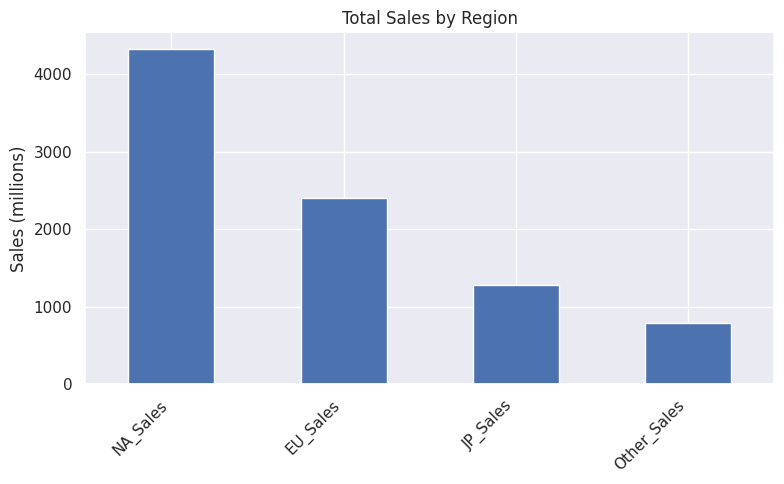

In [17]:
regional_sales = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

plt.figure(figsize=(8,5))
regional_sales.plot(kind='bar')
plt.title("Total Sales by Region")
plt.ylabel("Sales (millions)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*A bar chart was chosen to compare total sales across different regions of the world*
- North America (NA) is the largest gaming market by far
- Europe (EU) comes in second place
- Japan (JP) is the third despite being where many games originate
- Other regions have the lowest sales

### NA Sales vs EU Sales Relationship

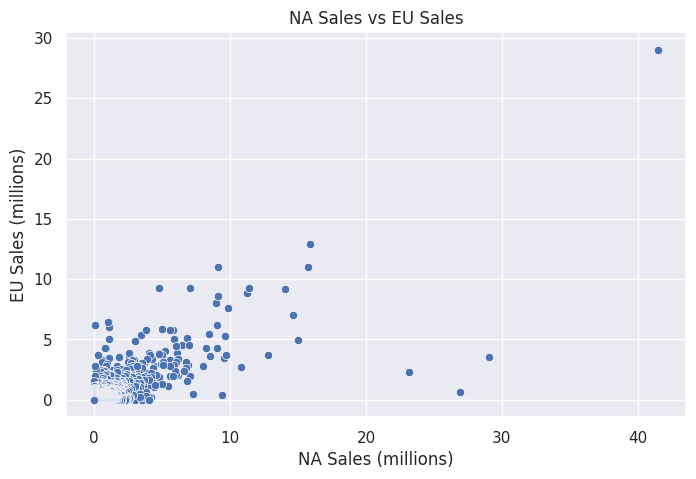

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='NA_Sales', y='EU_Sales', data=df)
plt.title("NA Sales vs EU Sales")
plt.xlabel("NA Sales (millions)")
plt.ylabel("EU Sales (millions)")
plt.show()

*A scatter plot was chosen to show the relationship and correlation between NA and EU sales*
- Most games have low sales in both NA and EU regions (clustered near (0,0))
- There is a positive relationship - games that sell well in NA tend to sell well in EU too
- The outlier at approximately (41,39) likely represents a blockbuster game like Wii Sports

## Time-Based Analysis
### Global Sales Trend by Year

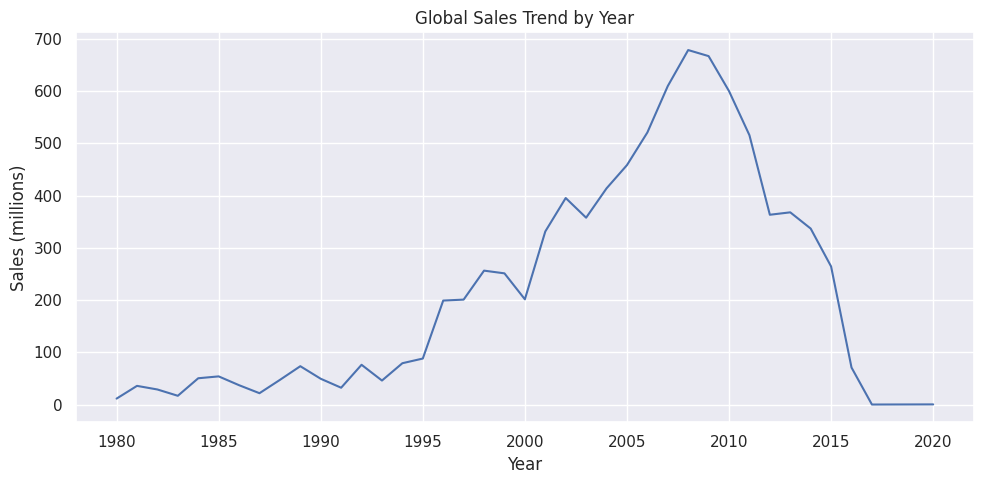

In [19]:
yearly_sales = df.groupby('Year')['Global_Sales'].sum()

plt.figure(figsize=(10,5))
yearly_sales.plot()
plt.title("Global Sales Trend by Year")
plt.ylabel("Sales (millions)")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

*A line chart was chosen to show how global sales changed over time*
- Global game sales peaked around 2007-2008
- This coincides with the release of major consoles: PS3, Xbox 360, and Wii
- Sales have declined after 2008, possibly due to rise of mobile gaming

### Correlation Matrix

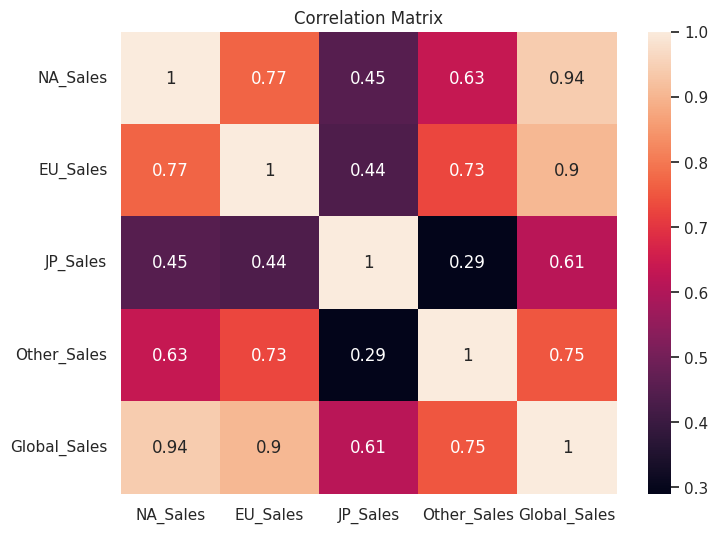

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

*A heatmap was chosen to clearly show the correlation strength between all numeric columns*
- NA_Sales and EU_Sales have the strongest correlation with global sales
- JP_Sales has a weaker correlation, suggesting Japanese gamers have different preferences
- All regions contribute to Global_Sales but NA and EU are the biggest drivers

## Conclusion

From this EDA on the Video Game Sales dataset, we found:
- Most games sell less than 2.5 million copies globally (right-skewed distribution)
- Action, Sports and Shooter are the top selling genres
- PS2 is the highest selling platform of all time
- Nintendo dominates the top 10 best selling games
- North America is the largest gaming market globally
- Game sales peaked around 2007-2008 with the rise of PS3, Xbox 360, and Wii